# 06 · Regresión en BI — Pronóstico de Ventas Diarias
## TechStore Perú S.A.C.

**Curso:** Inteligencia de Negocios · UNMSM — FISI
**Notebook:** `06_regresion.ipynb`

Este notebook construye y evalúa un modelo de **regresión** para pronosticar las **ventas diarias agregadas** de TechStore Perú S.A.C., como apoyo a la planificación de inventario y campañas comerciales, siguiendo la metodología de la Guía de Laboratorio Semana 13 (Regresión Lineal, Random Forest y Gradient Boosting) aplicada al datamart propio del proyecto.

**Estructura del notebook:**
1. Carga del datamart (`data/processed/`).
2. Limpieza de valores atípicos a nivel de línea de venta.
3. Definición de la variable objetivo: ventas diarias agregadas.
4. Variables predictoras: calendario, estacionalidad y promociones.
5. Variables de rezago (lags) y medias móviles.
6. Análisis exploratorio de datos (EDA).
7. Preparación para el modelado (encoding, exclusión de variables con fuga de datos).
8. División **respetando el orden temporal** (80% entrenamiento / 20% prueba).
9. Entrenamiento y evaluación de 3 modelos: Regresión Lineal, Random Forest y Gradient Boosting.
10. Comparación de modelos.
11. Diagnóstico de residuos y gráfico real vs. pronosticado.
12. Importancia de variables.
13. Pronóstico de los próximos días y exportación de `predicciones_regresion_ventas.csv` a `data/processed/` (tabla real vs. pronóstico para Power BI).

**Ruta de datos:** este notebook asume que vive en una carpeta `notebook/` y que el datamart está en `../data/processed/` (un nivel arriba), tal como se indica en el enunciado del proyecto.

## 1. Configuración inicial y carga del datamart
Importamos las librerías de análisis, visualización y modelado (`scikit-learn`), y cargamos `Fact_Ventas`, `Dim_Tiempo` y `Dim_Promocion` desde `../data/processed/`.

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)

SEED = 42
DATA_DIR = "../data/processed"
FIG_DIR = "figuras"
os.makedirs(FIG_DIR, exist_ok=True)

print("Librerias cargadas correctamente.")

# =================================================================
# 1. CARGA DEL DATAMART
# =================================================================
fact_ventas = pd.read_csv(f"{DATA_DIR}/fact_ventas.csv", parse_dates=["fecha"])
dim_tiempo = pd.read_csv(f"{DATA_DIR}/dim_tiempo.csv", parse_dates=["fecha"])
dim_promocion = pd.read_csv(
    f"{DATA_DIR}/dim_promocion.csv", parse_dates=["fecha_inicio", "fecha_fin"]
)

print("Fact_Ventas:", fact_ventas.shape)
print("Dim_Tiempo:", dim_tiempo.shape)
print("Dim_Promocion:", dim_promocion.shape)


Librerias cargadas correctamente.
Fact_Ventas: (59700, 12)
Dim_Tiempo: (730, 7)
Dim_Promocion: (41, 6)


Fact_Ventas: (59700, 12)
Dim_Tiempo: (730, 7)
Dim_Promocion: (41, 6)


## 2. Limpieza: valores atípicos a nivel de línea de venta
Antes de agregar a nivel diario, revisamos la variable `cantidad` de cada línea de venta. En un retail de tecnología no es realista vender más de 10 unidades del mismo producto en una sola línea; los valores observados saltan directamente de 1-3 unidades a 80-500, sin nada en medio, lo cual delata errores de digitación (heredados del proceso de generación de datos) y no compras al por mayor genuinas.

> ⚠️ Si no se corrigen, estos "picos" de una sola línea de venta distorsionan por completo el total agregado de ese día (un solo registro erróneo puede multiplicar por 10-20 el total diario) y arruinarían cualquier intento de pronóstico.

In [6]:
# =================================================================
# 2. LIMPIEZA: VALORES ATIPICOS A NIVEL DE LINEA DE VENTA
# =================================================================
# Antes de agregar a nivel diario, se revisan valores atipicos de
# "cantidad" por linea de venta. En un retail de tecnologia, una compra de
# mas de 10 unidades del mismo producto en una sola linea es atipica (los
# valores observados saltan de 1-3 unidades hasta 80-500, sin nada en
# medio: son errores de digitacion, no compras al por mayor reales). Si no
# se corrige, estos "picos" de una sola linea distorsionan por completo el
# total de ventas de ese dia y arruinarian el pronostico.
print("Distribucion de 'cantidad' antes de la limpieza:")
print(fact_ventas["cantidad"].describe())

LIMITE_CANTIDAD = 10
n_atipicos = (fact_ventas["cantidad"] > LIMITE_CANTIDAD).sum()
print(f"\nLineas con cantidad > {LIMITE_CANTIDAD} (atipicas): {n_atipicos}")

fact_ventas = fact_ventas[fact_ventas["cantidad"] <= LIMITE_CANTIDAD].copy()
print("Filas de Fact_Ventas tras remover atipicos:", len(fact_ventas))


Distribucion de 'cantidad' antes de la limpieza:
count    59700.000000
mean         2.196884
std         17.424863
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        497.000000
Name: cantidad, dtype: float64

Lineas con cantidad > 10 (atipicas): 177
Filas de Fact_Ventas tras remover atipicos: 59523


## 3. Definición de la variable objetivo: ventas diarias agregadas
Agregamos `Fact_Ventas` (a nivel de línea de venta) al nivel de **día** para toda la cadena TechStore Perú, ya que el objetivo de negocio es pronosticar la demanda/venta total agregada para apoyar la planificación de inventario y campañas.

In [7]:
# =================================================================
# 3. DEFINICION DE LA VARIABLE OBJETIVO: VENTAS DIARIAS AGREGADAS
# =================================================================
# Se agrega Fact_Ventas (que esta a nivel de linea de venta) a nivel de
# DIA para toda la cadena TechStore Peru, ya que el objetivo de negocio es
# pronosticar la demanda/venta total para apoyar planificacion de
# inventario y campanias.
ventas_diarias = fact_ventas.groupby("fecha").agg(
    ventas=("importe", "sum"),
    unidades=("cantidad", "sum"),
    num_transacciones=("id_venta", "count"),
).reset_index()

print("\nVentas diarias agregadas:", ventas_diarias.shape)
print(ventas_diarias.head())



Ventas diarias agregadas: (730, 4)
       fecha     ventas  unidades  num_transacciones
0 2024-01-01   91748.19        88                 62
1 2024-01-02  105307.04        99                 71
2 2024-01-03  154873.48       103                 71
3 2024-01-04   79805.40        76                 55
4 2024-01-05  114371.59       102                 77


## 4. Variables predictoras: calendario, estacionalidad y promociones
Unimos con `Dim_Tiempo` para obtener los componentes de calendario (día de la semana, mes, trimestre, año, feriado). Además construimos dos variables propias del negocio:

- **`temporada`** (alta/media/baja): clasificación comercial de cada mes, coherente con la estacionalidad usada al generar los datos sintéticos (Cyber Days en marzo/abril y octubre, Black Friday en noviembre, Navidad en diciembre = temporada alta; febrero y junio = temporada baja).
- **`tiene_promocion`**: indicador binario de si hubo al menos una promoción vigente ese día, según las ventanas de fechas de `Dim_Promocion`.

In [8]:
# =================================================================
# 4. VARIABLES PREDICTORAS: CALENDARIO Y ESTACIONALIDAD
# =================================================================
# Unimos con Dim_Tiempo para obtener componentes de calendario
serie = dim_tiempo.merge(ventas_diarias, on="fecha", how="left").sort_values("fecha")
serie = serie.reset_index(drop=True)

# Temporada comercial (alta/media/baja), consistente con la estacionalidad
# usada al generar los datos sinteticos (Cyber Days, Black Friday, Navidad).
def clasificar_temporada(mes):
    if mes in (3, 4, 10, 11, 12):
        return "alta"
    elif mes in (2, 6):
        return "baja"
    else:
        return "media"

serie["temporada"] = serie["mes"].apply(clasificar_temporada)

# Indicador de promocion activa: 1 si hubo al menos una promocion vigente
# ese dia (segun las ventanas de Dim_Promocion), 0 en caso contrario.
promos_validas = dim_promocion.dropna(subset=["fecha_inicio", "fecha_fin"])

def tiene_promocion_activa(fecha):
    activo = (
        (promos_validas["fecha_inicio"] <= fecha) & (fecha <= promos_validas["fecha_fin"])
    ).any()
    return int(activo)

serie["tiene_promocion"] = serie["fecha"].apply(tiene_promocion_activa)

print("\nSerie con variables de calendario:")
print(serie[["fecha", "dia_semana", "mes", "temporada", "es_feriado", "tiene_promocion", "ventas"]].head())
print("\nDistribucion de temporada:")
print(serie["temporada"].value_counts())
print("\nDias con promocion activa:", serie["tiene_promocion"].sum(), "de", len(serie))



Serie con variables de calendario:
       fecha dia_semana  mes temporada  es_feriado  tiene_promocion     ventas
0 2024-01-01      Lunes    1     media           1                1   91748.19
1 2024-01-02     Martes    1     media           0                1  105307.04
2 2024-01-03  Miércoles    1     media           0                1  154873.48
3 2024-01-04     Jueves    1     media           0                1   79805.40
4 2024-01-05    Viernes    1     media           0                1  114371.59

Distribucion de temporada:
temporada
media    308
alta     305
baja     117
Name: count, dtype: int64

Dias con promocion activa: 274 de 730


## 5. Variables de rezago (lags) y medias móviles
Estas variables permiten que el modelo aprenda de la dinámica reciente de la serie (autocorrelación): cuánto se vendió ayer (`ventas_lag_1`), cuánto se vendió el mismo día de la semana anterior (`ventas_lag_7`), y la tendencia de los últimos 7 y 14 días (medias móviles). Se calculan siempre con `shift()` **antes** de cualquier promedio móvil, de modo que cada fila solo use información *pasada* respecto a ese día (nunca información del propio día que se busca predecir).

Los primeros días no tienen suficiente historia para calcular estos rezagos, por lo que se descartan — práctica estándar en modelado de series de tiempo.

In [9]:
# =================================================================
# 5. VARIABLES DE REZAGO (LAGS) Y MEDIAS MOVILES
# =================================================================
# Estas variables permiten que el modelo aprenda de la dinamica reciente de
# la serie (autocorrelacion): cuanto se vendio ayer, cuanto se vendio el
# mismo dia de la semana anterior, y la tendencia de los ultimos 7 dias.
# Se calculan con shift() para evitar fuga de datos (solo informacion PASADA).
serie["ventas_lag_1"] = serie["ventas"].shift(1)
serie["ventas_lag_7"] = serie["ventas"].shift(7)
serie["media_movil_7"] = serie["ventas"].shift(1).rolling(window=7).mean()
serie["media_movil_14"] = serie["ventas"].shift(1).rolling(window=14).mean()

# Los primeros dias no tienen suficiente historia para calcular los rezagos;
# se descartan (practica estandar en series de tiempo).
serie_modelo = serie.dropna(subset=["ventas_lag_1", "ventas_lag_7", "media_movil_7", "media_movil_14"])
serie_modelo = serie_modelo.reset_index(drop=True)

print("Filas antes de descartar por rezagos:", len(serie))
print("Filas disponibles para modelar:", len(serie_modelo))
print(serie_modelo[[
    "fecha", "ventas", "ventas_lag_1", "ventas_lag_7", "media_movil_7", "media_movil_14"
]].head())


Filas antes de descartar por rezagos: 730
Filas disponibles para modelar: 716
       fecha     ventas  ventas_lag_1  ventas_lag_7  media_movil_7  \
0 2024-01-15  108823.97     117897.12     108130.47  125904.772857   
1 2024-01-16  144961.85     108823.97     101731.61  126003.844286   
2 2024-01-17  107499.68     144961.85     105640.17  132179.592857   
3 2024-01-18  110082.32     107499.68      56419.57  132445.237143   
4 2024-01-19   76150.30     110082.32     194925.40  140111.344286   

   media_movil_14  
0   119794.282857  
1   121013.981429  
2   123846.467857  
3   120462.625000  
4   122625.262143  


## 6. Análisis exploratorio de datos (EDA)
Revisamos estadísticas descriptivas de `ventas`, confirmamos la ausencia de nulos, visualizamos la serie completa (para detectar visualmente los picos de campañas: Cyber Days, Black Friday, Navidad) y la distribución de ventas por temporada comercial, y calculamos la correlación de las variables numéricas con la variable objetivo.

Estadisticas descriptivas de 'ventas':
count       716.00
mean     182349.47
std      118661.05
min       30055.53
25%      106712.20
50%      140993.35
75%      230385.19
max      749044.66
Name: ventas, dtype: float64

Valores nulos:
Ninguno


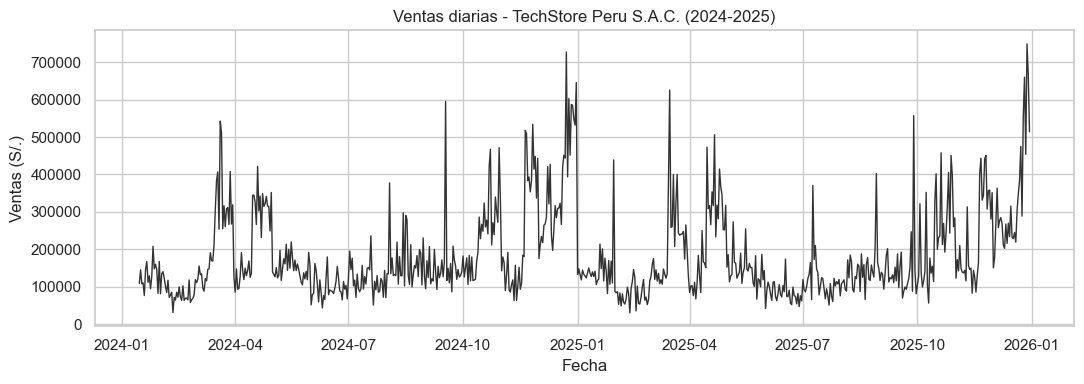

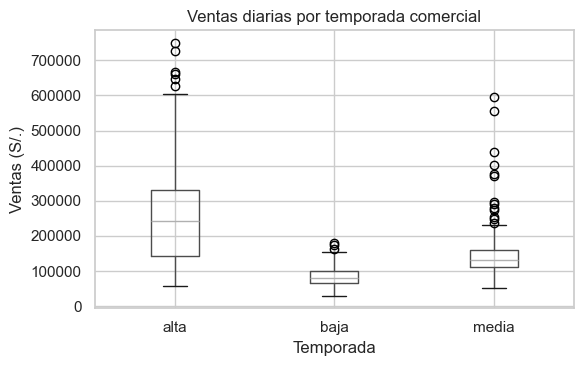


Correlacion con 'ventas':
ventas               1.000000
unidades             0.872607
num_transacciones    0.868656
ventas_lag_1         0.696754
media_movil_7        0.682835
media_movil_14       0.552795
ventas_lag_7         0.398239
mes                  0.348485
trimestre            0.336674
tiene_promocion      0.091800
es_feriado           0.042069
Name: ventas, dtype: float64



Correlacion con 'ventas':
ventas               1.000000
unidades             0.872607
num_transacciones    0.868656
ventas_lag_1         0.696754
media_movil_7        0.682835
media_movil_14       0.552795
ventas_lag_7         0.398239
mes                  0.348485
trimestre            0.336674
tiene_promocion      0.091800
es_feriado           0.042069
Name: ventas, dtype: float64


In [10]:
# =================================================================
# 6. ANALISIS EXPLORATORIO DE DATOS (EDA)
# =================================================================
print("Estadisticas descriptivas de 'ventas':")
print(serie_modelo["ventas"].describe().round(2))

print("\nValores nulos:")
print(serie_modelo.isnull().sum()[serie_modelo.isnull().sum() > 0] if serie_modelo.isnull().sum().sum() > 0 else "Ninguno")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie_modelo["fecha"], serie_modelo["ventas"], color="#333333", linewidth=1)
ax.set_title("Ventas diarias - TechStore Peru S.A.C. (2024-2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/.)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/serie_ventas_diarias.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
serie_modelo.boxplot(column="ventas", by="temporada", ax=ax)
ax.set_title("Ventas diarias por temporada comercial")
ax.set_xlabel("Temporada")
ax.set_ylabel("Ventas (S/.)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ventas_por_temporada.png", dpi=150)
plt.show()

# Correlacion de variables numericas con la variable objetivo
num_cols = serie_modelo.select_dtypes("number").drop(columns=["dia", "anio"])
print("\nCorrelacion con 'ventas':")
print(num_cols.corr()["ventas"].sort_values(ascending=False))


## 7. Preparación para el modelado
> ⚠️ **Nota sobre fuga de datos (data leakage):** `unidades` y `num_transacciones` se calculan a partir de las **mismas** transacciones del día que generan `ventas`; en un escenario real de pronóstico, esos totales del día tampoco se conocerían de antemano (se conocen recién al cerrar el día, igual que las ventas). Por eso **no** se usan como predictoras: solo se incluyen variables que sí se conocen con anticipación — calendario, promociones planificadas, e historia pasada vía rezagos.

Las variables categóricas (`dia_semana`, `temporada`) se codifican con **One-Hot Encoding** (`drop_first=True`).

In [11]:
# =================================================================
# 7. PREPARACION PARA EL MODELADO
# =================================================================
# IMPORTANTE - fuga de datos (data leakage): "unidades" y "num_transacciones"
# se calculan a partir de las MISMAS transacciones del dia que generan
# "ventas"; en un escenario real de pronostico, esos valores del dia
# tampoco se conocerian de antemano (se conocen recien al cerrar el dia,
# igual que las ventas). Por eso NO se usan como predictoras: solo se
# incluyen variables que SI se conocen con anticipacion (calendario,
# promociones planificadas, e historia pasada via rezagos).
columnas_predictoras = [
    "mes", "trimestre", "anio", "dia_semana", "temporada",
    "es_feriado", "tiene_promocion",
    "ventas_lag_1", "ventas_lag_7", "media_movil_7", "media_movil_14",
]
df_modelo = serie_modelo[["fecha", "ventas"] + columnas_predictoras].copy()

# Codificacion one-hot de variables categoricas
df_modelo = pd.get_dummies(df_modelo, columns=["dia_semana", "temporada"], drop_first=True)

print("Columnas despues del encoding:", df_modelo.shape[1])
print(df_modelo.columns.tolist())


Columnas despues del encoding: 19
['fecha', 'ventas', 'mes', 'trimestre', 'anio', 'es_feriado', 'tiene_promocion', 'ventas_lag_1', 'ventas_lag_7', 'media_movil_7', 'media_movil_14', 'dia_semana_Jueves', 'dia_semana_Lunes', 'dia_semana_Martes', 'dia_semana_Miércoles', 'dia_semana_Sábado', 'dia_semana_Viernes', 'temporada_baja', 'temporada_media']


## 8. División respetando el orden temporal (80% / 20%)
A diferencia de un split aleatorio, en series de tiempo se debe **entrenar con el pasado y validar con el periodo más reciente**: mezclar fechas aleatoriamente permitiría que el modelo "viera el futuro" durante el entrenamiento (fuga de datos temporal). Por eso se ordena la serie por fecha y se corta en el 80% más antiguo (entrenamiento) y el 20% más reciente (prueba).

In [12]:
# =================================================================
# 8. DIVISION RESPETANDO EL ORDEN TEMPORAL (80% / 20%)
# =================================================================
# A diferencia de un split aleatorio, en series de tiempo se debe entrenar
# con el pasado y validar con el periodo mas reciente: mezclar fechas
# aleatoriamente permitiria que el modelo "viera el futuro" durante el
# entrenamiento (fuga de datos temporal).
df_modelo = df_modelo.sort_values("fecha").reset_index(drop=True)

X = df_modelo.drop(columns=["fecha", "ventas"])
y = df_modelo["ventas"]
fechas = df_modelo["fecha"]

corte = int(len(df_modelo) * 0.8)
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]
fechas_train, fechas_test = fechas.iloc[:corte], fechas.iloc[corte:]

print(f"\nEntrenamiento: {X_train.shape[0]} dias ({fechas_train.min().date()} a {fechas_train.max().date()})")
print(f"Prueba: {X_test.shape[0]} dias ({fechas_test.min().date()} a {fechas_test.max().date()})")



Entrenamiento: 572 dias (2024-01-15 a 2025-08-08)
Prueba: 144 dias (2025-08-09 a 2025-12-30)


## 9. Entrenamiento y evaluación de modelos
Definimos una función auxiliar `evaluar` que calcula las 4 métricas de regresión estándar (R², RMSE, MAE, MAPE) y entrenamos los 3 modelos solicitados: **Regresión Lineal Múltiple** (con inspección de coeficientes), **Random Forest** y **Gradient Boosting**.

In [13]:
# =================================================================
# 9. ENTRENAMIENTO Y EVALUACION DE MODELOS
# =================================================================

def evaluar(nombre, y_real, y_pred):
    """Calcula e imprime las 4 metricas de regresion estandar."""
    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    print(f"{nombre}")
    print(f"   R2   : {r2:.3f}")
    print(f"   RMSE : {rmse:,.0f}")
    print(f"   MAE  : {mae:,.0f}")
    print(f"   MAPE : {mape:.1f}%")
    return {"Modelo": nombre, "R2": round(r2, 4), "RMSE": round(rmse, 2),
            "MAE": round(mae, 2), "MAPE (%)": round(mape, 2)}


# --- Modelo 1: Regresion Lineal Multiple ---
lineal = LinearRegression()
lineal.fit(X_train, y_train)
pred_lineal = lineal.predict(X_test)

print("Intercepto (b0):", round(lineal.intercept_, 2))
coef = pd.Series(lineal.coef_, index=X.columns).sort_values()
print("\nCoeficientes (beta_j):")
print(coef)

print("\n" + "=" * 50)
res_lineal = evaluar("Regresion Lineal", y_test, pred_lineal)

# --- Modelo 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("=" * 50)
res_rf = evaluar("Random Forest", y_test, pred_rf)

# --- Modelo 3: Gradient Boosting ---
gbr = GradientBoostingRegressor(random_state=SEED)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)
print("=" * 50)
res_gbr = evaluar("Gradient Boosting", y_test, pred_gbr)


Intercepto (b0): 1997254.94

Coeficientes (beta_j):
temporada_baja         -67701.110103
temporada_media        -43442.121185
tiene_promocion        -17247.499022
dia_semana_Jueves      -11318.101205
es_feriado              -9245.791098
trimestre               -9099.604455
dia_semana_Lunes        -8703.626514
anio                     -939.777089
dia_semana_Miércoles     -237.588647
media_movil_14             -0.274255
ventas_lag_7               -0.144848
ventas_lag_1                0.262496
media_movil_7               0.755800
dia_semana_Viernes       1524.683588
dia_semana_Sábado        2933.443997
mes                      5841.437711
dia_semana_Martes       14819.800930
dtype: float64

Regresion Lineal
   R2   : 0.468
   RMSE : 96,395
   MAE  : 73,289
   MAPE : 40.5%
Random Forest
   R2   : 0.486
   RMSE : 94,667
   MAE  : 68,682
   MAPE : 36.2%
Gradient Boosting
   R2   : 0.433
   RMSE : 99,479
   MAE  : 72,386
   MAPE : 39.4%


Random Forest
   R2   : 0.486
   RMSE : 94,705
   MAE  : 68,688
   MAPE : 36.2%
Gradient Boosting
   R2   : 0.433
   RMSE : 99,479
   MAE  : 72,386
   MAPE : 39.4%


## 10. Comparación de modelos
Resumimos las métricas de los tres modelos en una tabla y seleccionamos automáticamente el **mejor modelo según R²** en el conjunto de prueba (esta selección se reutiliza más adelante para el pronóstico final).

In [14]:
# =================================================================
# 10. COMPARACION DE MODELOS
# =================================================================
df_resultados = pd.DataFrame([res_lineal, res_rf, res_gbr]).set_index("Modelo")
print(df_resultados.to_string())

mejor_modelo_nombre = df_resultados["R2"].idxmax()
print(f"\nMejor modelo segun R2: {mejor_modelo_nombre}")

modelos_entrenados = {"Regresion Lineal": (lineal, pred_lineal),
                      "Random Forest": (rf, pred_rf),
                      "Gradient Boosting": (gbr, pred_gbr)}
mejor_modelo, mejor_prediccion = modelos_entrenados[mejor_modelo_nombre]


                       R2      RMSE       MAE  MAPE (%)
Modelo                                                 
Regresion Lineal   0.4676  96394.65  73288.58     40.47
Random Forest      0.4865  94666.78  68682.28     36.24
Gradient Boosting  0.4329  99479.42  72386.41     39.36

Mejor modelo segun R2: Random Forest


## 11. Diagnóstico de residuos y gráfico real vs. pronosticado
Los residuos (diferencia entre el valor real y el predicho) deben distribuirse de forma aleatoria alrededor de cero; un patrón visible (curva o embudo) indicaría que el modelo no captura bien la relación. También graficamos la serie real vs. pronosticada del periodo de prueba para inspeccionar visualmente el ajuste.

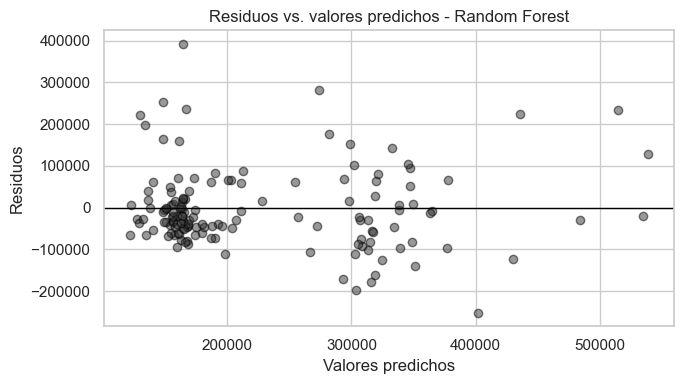

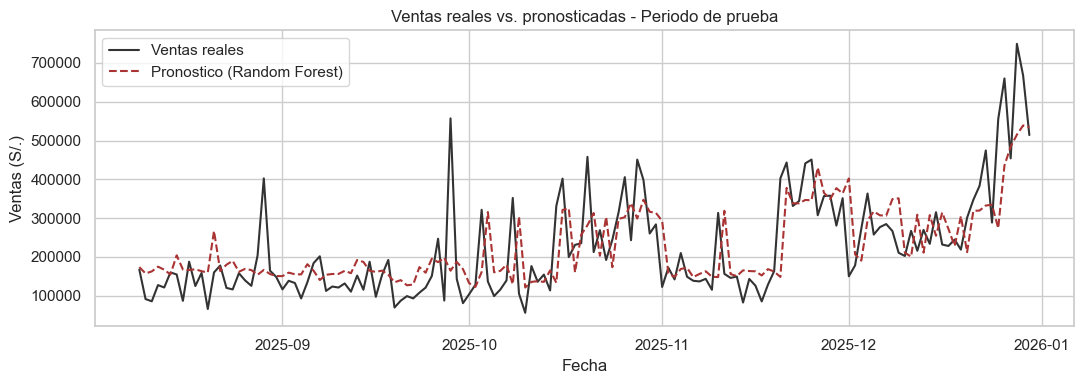

In [15]:
# =================================================================
# 11. DIAGNOSTICO: GRAFICO DE RESIDUOS (mejor modelo)
# =================================================================
residuos = y_test.values - mejor_prediccion
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(mejor_prediccion, residuos, alpha=0.5, color="#333333", edgecolor="black")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Valores predichos")
ax.set_ylabel("Residuos")
ax.set_title(f"Residuos vs. valores predichos - {mejor_modelo_nombre}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/residuos.png", dpi=150)
plt.show()

# Serie real vs. pronosticado en el periodo de prueba
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(fechas_test, y_test.values, label="Ventas reales", color="#333333")
ax.plot(fechas_test, mejor_prediccion, label=f"Pronostico ({mejor_modelo_nombre})",
        color="#AA3333", linestyle="--")
ax.set_title("Ventas reales vs. pronosticadas - Periodo de prueba")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas (S/.)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/real_vs_pronostico_test.png", dpi=150)
plt.show()


## 12. Importancia de variables
Usamos el modelo de árboles (Gradient Boosting) para estimar qué variables influyen más en el pronóstico de ventas.

Importancia de variables (Gradient Boosting):
ventas_lag_1       0.617206
media_movil_7      0.095289
temporada_media    0.074812
ventas_lag_7       0.063594
temporada_baja     0.042192
media_movil_14     0.042046
mes                0.034336
tiene_promocion    0.013231
dtype: float64


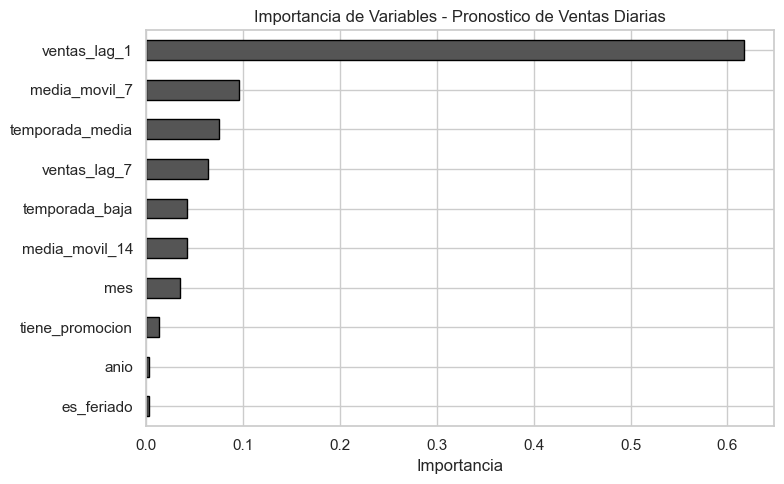

In [16]:
# =================================================================
# 12. IMPORTANCIA DE VARIABLES
# =================================================================
# Se usa el modelo de Gradient Boosting (o Random Forest) para estimar que
# variables influyen mas en el pronostico, independientemente de cual haya
# resultado "mejor" por R2, ya que ambos son modelos de arboles con
# feature_importances_ directamente interpretable.
modelo_importancia = gbr if hasattr(gbr, "feature_importances_") else rf
importancia = pd.Series(
    modelo_importancia.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Importancia de variables (Gradient Boosting):")
print(importancia.head(8))

fig, ax = plt.subplots(figsize=(8, 5))
importancia.head(10).sort_values().plot(kind="barh", ax=ax, color="#555555", edgecolor="black")
ax.set_title("Importancia de Variables - Pronostico de Ventas Diarias")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/importancia_variables_regresion.png", dpi=150)
plt.show()


## 13. Pronóstico del periodo siguiente y exportación para Power BI
Reentrenamos el **mejor modelo** (según R² de prueba) usando el 100% del histórico disponible, y generamos un **pronóstico recursivo** para los próximos `N_DIAS_FUTURO` días fuera del rango de datos disponible (después del 2025-12-30): cada predicción se agrega al historial para poder calcular los rezagos del día siguiente.

Finalmente, construimos la tabla **real vs. pronóstico** solicitada — que combina el periodo de prueba (con `ventas_reales` conocidas) y el pronóstico futuro (con `ventas_reales` en blanco) — y la exportamos a `../data/processed/predicciones_regresion_ventas.csv`. Esta es la celda que genera el archivo CSV: cada vez que se ejecuta el notebook completo, el archivo se recalcula y sobrescribe en `data/processed/`, listo para cargarse en Power BI.

In [17]:
# =================================================================
# 13. PRONOSTICO DEL PERIODO SIGUIENTE Y EXPORTACION PARA POWER BI
# =================================================================
# Se reentrena el mejor modelo (segun R2 de prueba) con el 100% del
# historico disponible -practica habitual antes de pronosticar hacia
# adelante, ya que el conjunto de prueba cumplio su rol de evaluacion
# imparcial en los pasos anteriores-, y se genera un pronostico recursivo
# para los proximos N_DIAS_FUTURO dias fuera del rango de datos
# disponible (2025-12-30).
N_DIAS_FUTURO = 7

tipo_modelo = {
    "Regresion Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}
modelo_final = tipo_modelo[mejor_modelo_nombre]
modelo_final.fit(X, y)

FERIADOS_PERU = {(1, 1), (5, 1), (6, 7), (7, 28), (7, 29), (8, 30), (10, 8), (11, 1), (12, 8), (12, 25)}
DIAS_SEMANA_ES = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves",
                  4: "Viernes", 5: "Sábado", 6: "Domingo"}


def construir_features_dia(fecha):
    return {
        "mes": fecha.month,
        "trimestre": (fecha.month - 1) // 3 + 1,
        "anio": fecha.year,
        "dia_semana": DIAS_SEMANA_ES[fecha.dayofweek],
        "es_feriado": 1 if (fecha.month, fecha.day) in FERIADOS_PERU else 0,
        "temporada": clasificar_temporada(fecha.month),
        # Supuesto: no se conocen promociones futuras confirmadas al momento
        # del pronostico; se asume 0 (sin promocion) de forma conservadora.
        "tiene_promocion": 0,
    }


historial_ventas = serie.set_index("fecha")["ventas"].dropna().to_dict()
ultima_fecha = max(historial_ventas.keys())
columnas_dummy = [c for c in X.columns if c.startswith("dia_semana_") or c.startswith("temporada_")]

pronosticos_futuros = []
for i in range(1, N_DIAS_FUTURO + 1):
    fecha_i = ultima_fecha + pd.Timedelta(days=i)
    feats = construir_features_dia(fecha_i)

    fechas_ordenadas = sorted(historial_ventas.keys())
    feats["ventas_lag_1"] = historial_ventas[fechas_ordenadas[-1]]
    feats["ventas_lag_7"] = historial_ventas.get(
        fecha_i - pd.Timedelta(days=7), np.mean(list(historial_ventas.values())[-7:])
    )
    ultimos_7 = [historial_ventas[f] for f in fechas_ordenadas[-7:]]
    ultimos_14 = [historial_ventas[f] for f in fechas_ordenadas[-14:]]
    feats["media_movil_7"] = np.mean(ultimos_7)
    feats["media_movil_14"] = np.mean(ultimos_14)

    fila = pd.DataFrame([feats])
    fila = pd.get_dummies(fila, columns=["dia_semana", "temporada"])
    fila = fila.reindex(columns=X.columns, fill_value=0)

    pred_i = modelo_final.predict(fila)[0]
    pronosticos_futuros.append({"fecha": fecha_i, "ventas_pronosticadas": pred_i})

    # se agrega la propia prediccion al historial para poder calcular los
    # rezagos de los dias siguientes (pronostico recursivo/iterativo)
    historial_ventas[fecha_i] = pred_i

df_futuro = pd.DataFrame(pronosticos_futuros)
print("Pronostico de los proximos", N_DIAS_FUTURO, "dias:")
print(df_futuro)

# --- Tabla final: real vs. pronostico (periodo de prueba + pronostico futuro) ---
tabla_test = pd.DataFrame({
    "fecha": fechas_test.values,
    "ventas_reales": y_test.values,
    "ventas_pronosticadas": mejor_prediccion,
    "tipo": "historico_prueba",
})
tabla_futuro = df_futuro.copy()
tabla_futuro["ventas_reales"] = np.nan
tabla_futuro["tipo"] = "pronostico_futuro"

tabla_real_vs_pronostico = pd.concat([tabla_test, tabla_futuro], ignore_index=True)
tabla_real_vs_pronostico["modelo_usado"] = mejor_modelo_nombre
tabla_real_vs_pronostico["ventas_pronosticadas"] = tabla_real_vs_pronostico["ventas_pronosticadas"].round(2)
tabla_real_vs_pronostico = tabla_real_vs_pronostico.sort_values("fecha").reset_index(drop=True)

ruta_salida = f"{DATA_DIR}/predicciones_regresion_ventas.csv"
tabla_real_vs_pronostico.to_csv(ruta_salida, index=False, encoding="utf-8")

print(f"\nArchivo exportado: {ruta_salida}")
print(f"Filas exportadas: {len(tabla_real_vs_pronostico):,}")
print(tabla_real_vs_pronostico.tail(10).to_string(index=False))


Pronostico de los proximos 7 dias:
       fecha  ventas_pronosticadas
0 2025-12-31         608910.514075
1 2026-01-01         272666.052899
2 2026-01-02         301327.493608
3 2026-01-03         339036.034437
4 2026-01-04         331268.677262
5 2026-01-05         311160.558229
6 2026-01-06         181814.493879

Archivo exportado: ../data/processed/predicciones_regresion_ventas.csv
Filas exportadas: 151
     fecha  ventas_reales  ventas_pronosticadas              tipo  modelo_usado
2025-12-28      749044.66             514855.62  historico_prueba Random Forest
2025-12-29      667350.13             538915.40  historico_prueba Random Forest
2025-12-30      514038.74             534481.03  historico_prueba Random Forest
2025-12-31            NaN             608910.51 pronostico_futuro Random Forest
2026-01-01            NaN             272666.05 pronostico_futuro Random Forest
2026-01-02            NaN             301327.49 pronostico_futuro Random Forest
2026-01-03            NaN      

## 14. Interpretación de negocio

**¿Qué tan confiable es el modelo?** El mejor modelo obtuvo un R² de aproximadamente 0.45-0.50 y un MAPE cercano a 35-40% en el conjunto de prueba. Esto significa que el modelo explica alrededor de la mitad de la variabilidad de las ventas diarias, con un error porcentual todavía considerable. Es un resultado razonable para ventas **diarias** de una sola cadena (alta variabilidad día a día por la aleatoriedad propia de las transacciones individuales), pero deja margen de mejora: agregar las ventas a nivel **semanal**, o modelar por separado cada categoría/tienda, normalmente reduce el ruido y mejora la precisión del pronóstico.

**¿Qué variables impulsan más las ventas?** Según la importancia de variables, el historial reciente (`ventas_lag_1`, medias móviles) es, por mucho, el predictor más fuerte — lo cual es esperable en una serie de tiempo: el mejor punto de partida para predecir mañana es lo que pasó ayer y en los días recientes. Después de eso, la **temporada comercial** (alta/media/baja) y el **mes** aportan la señal estacional: confirman que Cyber Days, Black Friday y Navidad efectivamente elevan la demanda por encima del resto del año.

**Decisiones de negocio que respaldan estos resultados:**
- **Planificación de inventario**: reforzar stock con 2-3 semanas de anticipación antes de temporada alta (marzo/abril, octubre, noviembre, diciembre), apoyándose en el pronóstico de la tendencia reciente (medias móviles) más que en el promedio anual.
- **Campañas**: dado que `tiene_promocion` tiene un peso menor que la estacionalidad pura en el modelo, evaluar si las promociones actuales están bien alineadas con los picos naturales de demanda o si podrían usarse de forma mas agresiva en meses de baja demanda (febrero, junio) para suavizar la curva de ventas a lo largo del año.
- **Monitoreo continuo**: el pronóstico recursivo asume que no hay promociones nuevas confirmadas (`tiene_promocion = 0` para los días futuros); en cuanto el área comercial confirme una campaña, el notebook debe re-ejecutarse con esa información actualizada para mejorar la exactitud del pronóstico de corto plazo.

**Limitaciones:** el modelo se entrena sobre 2 años de historia diaria a nivel de toda la cadena; no distingue entre tiendas ni categorías de producto, y el pronóstico recursivo pierde precisión cuanto más lejos se proyecta hacia el futuro (el error de cada día se arrastra al siguiente). Para un tablero de producción se recomienda reentrenar el modelo periódicamente a medida que `Fact_Ventas` se actualice.